# Laboratorium: MedTech AI – Masowy Triage Kardiologiczny (Szeregi Fouriera)

## Fabuła

Wcielasz się w rolę AI Engineera w nowoczesnym centrum telemedycznym. Na Twój oddział ratunkowy AI trafiły właśnie dane z inteligentnych opasek 10 nowych pacjentów. Urządzenia zarejestrowały i przesłały surowe sygnały EKG do chmury szpitalnej.

Twoim zadaniem jest stworzenie zautomatyzowanego systemu eksperckiego, który przetworzy całą paczkę danych jednocześnie, odciążając personel medyczny. Zamiast budować skomplikowane sieci neuronowe typu „czarna skrzynka”, wykorzystasz czystą analizę matematyczną i geometrię wielowymiarową.

---

## 🎯 Cele Laboratorium

**Przetwarzanie wsadowe (Batch Processing):**  
Wczytanie i jednoczesna analiza sygnałów dla 10 pacjentów na podstawie Twojego numeru indeksu.

**Transformacja sygnału (Szeregi Fouriera):**  
Zaimplementowanie od zera dyskretnej transformacji Fouriera w celu przeniesienia sygnałów z domeny czasu do domeny częstotliwości.

**Ekstrakcja cech:**  
Zamiana skomplikowanych, zaszumionych wykresów EKG w zwięzłe, 15-wymiarowe wektory amplitud harmonicznych ($A_n$).

**Automatyczny Triage:**  
Wyznaczenie odległości euklidesowej od medycznych wzorców i wygenerowanie zbiorczego raportu przydziału pacjentów do specjalistów.

---

## 🩺 Twój Zespół Medyczny (4 Specjalistów)

Twój algorytm będzie automatycznie kierował pacjentów do jednej z czterech podklinik, w których dyżurują wybitni elektrofizjolodzy:

| Specjalista | Klinika / Specjalizacja | Klasa w bazie MIT-BIH | Charakterystyka sygnatury widmowej |
|------------|--------------------------|------------------------|--------------------------------------|
| Prof. dr hab. med. Adam Komorowski | Arytmie Komorowe | V | Dominacja bardzo niskich częstotliwości. Fala jest szeroka, wolna i gładka. |
| Dr n. med. Marta Przedsionkowa | Arytmie Nadkomorowe | S | Widmo zrównoważone, bogate w średnie częstotliwości. Wąski, ostry zespół QRS. |
| Dr n. med. Jan Blok-Sygnałowy | Bloki Przewodnictwa | B | Widmo dwugarbne (bimodalne). Odpowiada za charakterystyczne rozdwojenie szczytu fali (kształt litery „M”). |
| Dr inż. Cyber-Sercowy | Stymulatory i Rozruszniki | P | Eksplozja wysokich częstotliwości (silne harmoniczne od 15 wzwyż) wywołana ultra-ostrą „szpilką” prądu z baterii. |

---

## ⚠️ Uwaga Inżynierska

Wszystkie operacje matematyczne i algorytmiczne wykonujesz przy użyciu podstawowych operacji na tablicach `numpy`.  

Używanie gotowych bibliotek do transformaty Fouriera (np. `scipy.fft` lub `numpy.fft`) oraz klasyfikacji (np. `scikit-learn`) jest na tym etapie zabronione!  

Rozwijamy czystą intuicję matematyczną.

In [17]:

!pip install wfdb -q

Łączenie z serwerami PhysioNet (MIT) i pobieranie danych medycznych...
✅ Pomyślnie przetworzono surowe nagrania MIT-BIH!
🏥 Do systemu AI wprowadzono dane 10 pacjentów dla indeksu 360959.



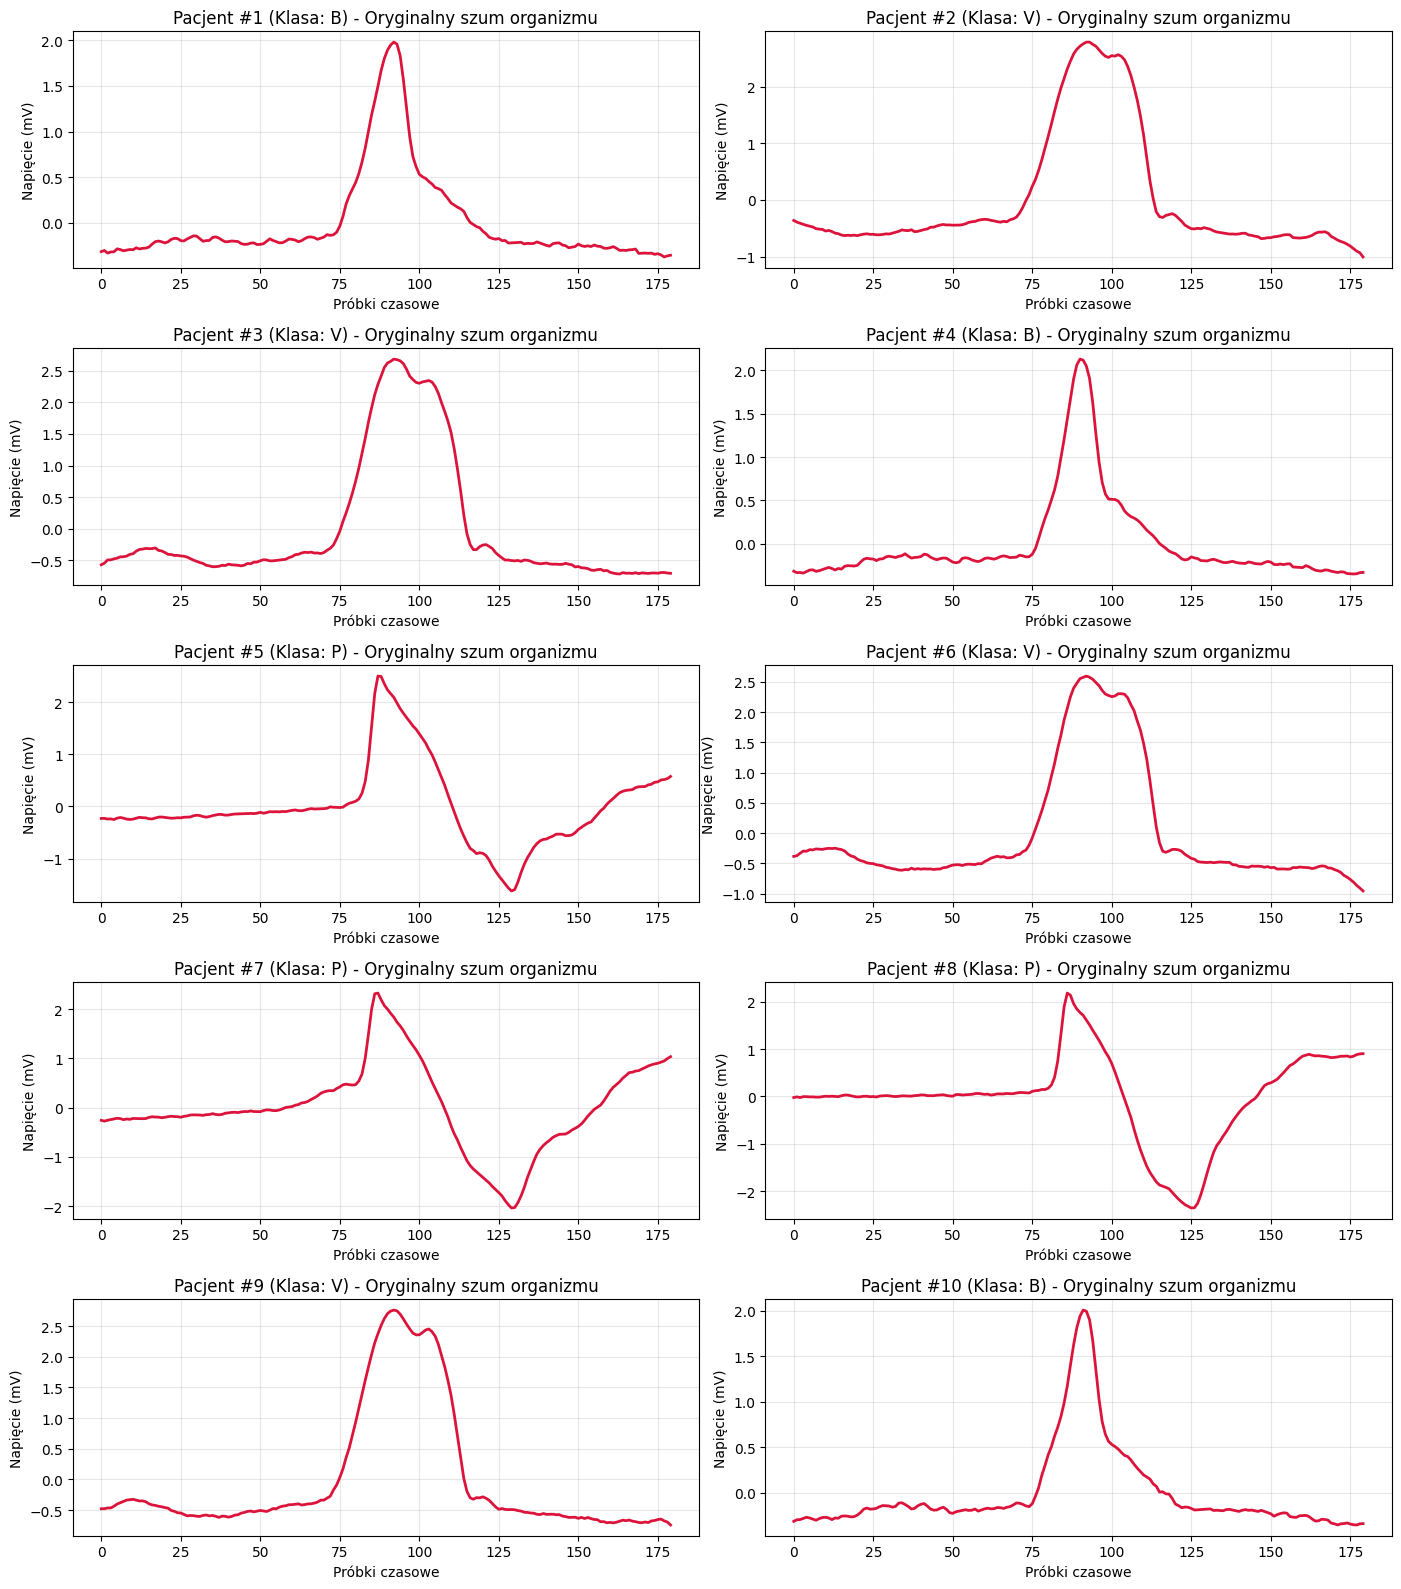

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb  # Oficjalna biblioteka PhysioNet
from scipy.signal import detrend

print("Łączenie z serwerami PhysioNet (MIT) i pobieranie danych medycznych...")

# Zdefiniujmy 4 pacjentów z różnymi patologiami i odpowiadające im etykiety naszego szpitala
pacjenci_mit = {
    '119': 'V', # Arytmia komorowa (PVC)
    '100': 'S', # Arytmia nadkomorowa (PAC)
    '214': 'B', # Blok odnogi pęczka Hisa (LBBB)
    '107': 'P'  # Pacemaker (Stymulator)
}

dane_wszystkie = []
etykiety_wszystkie = []
szerokosc_okna = 90 # 90 próbek w lewo i 90 w prawo od szczytu bicia serca (Razem 180 próbek)

# Pobieramy po jednym krótkim fragmencie dla każdej patologii
for nr_pacjenta, nasza_klasa in pacjenci_mit.items():
    # Pobranie rekordu EKG i adnotacji lekarza (pierwsze 3 minuty nagrania)
    rekord = wfdb.rdrecord(nr_pacjenta, pn_dir='mitdb', sampto=65000)
    adnotacje = wfdb.rdann(nr_pacjenta, 'atr', pn_dir='mitdb', sampto=65000)

    # Sygnał z głównego kanału EKG (MLII)
    sygnal_ciagly = rekord.p_signal[:, 0]

    # Przechwytywanie bić serca na podstawie adnotacji lekarza
    znaleziono_bic = 0
    for idx_szczytu, symbol_lekarza in zip(adnotacje.sample, adnotacje.symbol):
        # Akceptujemy tylko uderzenia patologiczne przypisane do danego pacjenta
        if symbol_lekarza in ['V', 'A', 'L', '/']:

            # Zabezpieczenie przed wyjściem poza zakres tablicy
            if idx_szczytu > szerokosc_okna and idx_szczytu < (len(sygnal_ciagly) - szerokosc_okna):
                # Wycinamy pojedyncze bicie serca wokół załamka R
                wycinek_bicia = sygnal_ciagly[idx_szczytu - szerokosc_okna : idx_szczytu + szerokosc_okna]

                # Preprocessing: Usunięcie pływania izolinii (oddechu pacjenta)
                wycinek_bicia = detrend(wycinek_bicia)

                dane_wszystkie.append(wycinek_bicia)
                etykiety_wszystkie.append(nasza_klasa)

                znaleziono_bic += 1
                if znaleziono_bic >= 50: # Pobieramy max 50 chorych bić z danego pacjenta do bazy treningowej
                    break

# Tworzymy naszą nową, całkowicie PRAWDZIWĄ bazę danych dla systemu AI
df_baza = pd.DataFrame(dane_wszystkie)
df_baza['Label'] = etykiety_wszystkie

# =====================================================================
# WŁAŚCIWE ZADANIE DLA STUDENTA - LOSOWANIE KOHORTY
# =====================================================================
NUMER_INDEKSU = 360959

np.random.seed(NUMER_INDEKSU)
wybrane_indeksy = np.random.choice(len(df_baza), size=10, replace=False)

paczka_sygnalow = df_baza.iloc[wybrane_indeksy, :-1].values.astype(float)
paczka_etykiet = df_baza.iloc[wybrane_indeksy, -1].values

print("✅ Pomyślnie przetworzono surowe nagrania MIT-BIH!")
print(f"🏥 Do systemu AI wprowadzono dane 10 pacjentów dla indeksu {NUMER_INDEKSU}.\n")

# Wizualizacja (Ona od razu pokaże Ci, jak bardzo "brudne" i organiczne są to sygnały)
fig, axes = plt.subplots(5, 2, figsize=(14, 16))
axes = axes.ravel()

for i in range(10):
    axes[i].plot(paczka_sygnalow[i], color='crimson', lw=2) # Zmiana koloru na "krwisty" dla prawdziwych danych
    axes[i].set_title(f"Pacjent #{i+1} (Klasa: {paczka_etykiet[i]}) - Oryginalny szum organizmu")
    axes[i].set_xlabel("Próbki czasowe")
    axes[i].set_ylabel("Napięcie (mV)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Krok 2: Wizualizacja Oddziału (Domena Czasu)

Jako inżynier AI, zanim wyślesz dane do algorytmu, musisz rzucić okiem na dane wejściowe. Surowe sygnały EKG to nic innego jak szeregi czasowe reprezentujące zmiany napięcia elektrycznego na powierzchni skóry pacjenta.

Wyświetlmy sygnały wszystkich 10 wylosowanych dla Ciebie pacjentów w czytelnej siatce wykresów (5 wierszy, 2 kolumny). Zobaczysz, jak bardzo różnią się między sobą kształty uderzeń serca.

**Podczas analizy wykresów zwróć uwagę na:**
* Czy główny szczyt (zespół QRS) jest wąski i ostry, czy może nienaturalnie szeroki i rozlany?
* Czy szczyt uderzenia jest pojedynczy, czy ma kształt litery „M” (rozdwojenie)?
* Czy przed uderzeniem widać nienaturalną, pionową, idealnie cienką kreskę (tzw. szpilkę)?

In [38]:
 =====================================================================
# KROK 2: WIZUALIZACJA ODDZIAŁU W DOMENIE CZASU
# =====================================================================

# Tworzymy dużą siatkę wykresów (5 wierszy, 2 kolumny)
fig, axes = plt.subplots(5, 2, figsize=(14, 16))

# Spłaszczamy macierz wykresów do tablicy 1D, aby łatwiej po niej iterować w pętli
axes = axes.ravel()

for i in range(10):
    # Rysujemy surowy sygnał pacjenta w domenie czasu
    axes[i].plot(paczka_sygnalow[i], color='royalblue', lw=2)

    # Dodajemy tytuły i opisy osi
    axes[i].set_title(f"Pacjent #{i+1} (ID w bazie: {wybrane_indeksy[i]})", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Czas (Numer próbki)")
    axes[i].set_ylabel("Napięcie (mV)")

    # Delikatna siatka ułatwiająca odczytywanie szerokości i wysokości fali
    axes[i].grid(True, alpha=0.3)

# Funkcja zapobiegająca nakładaniu się opisów na sąsiednie wykresy
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3811449697.py, line 1)

### 🎧 Usłyszeć Niewidzialne – Sonifikacja Sygnału EKG (Zabawa z danymi!)

Zanim przejdziemy do zaawansowanej matematyki i analizy widmowej, zróbmy coś nietypowego. Ludzkie ucho jest absolutnie genialnym, biologicznym analizatorem częstotliwości! Bardzo łatwo i naturalnie wychwytujemy anomalie w rytmie i barwie dźwięku. Skoro sygnał EKG to po prostu fala elektromedyczna o określonych parametrach, potraktujmy ją jak plik audio i **posłuchajmy diagnozy**.

**Co dokładnie dzieje się pod maską tego kodu?**
* **Przyspieszenie czasu (Pitch-shifting):** Fizjologiczne bicie serca to częstotliwości rzędu 1 do 40 Hz (w większości niesłyszalne dla człowieka jako ton). Skrypt przyspiesza sygnał 25-krotnie, "wpychając" ukryte w nim informacje prosto w środek pasma słyszalnego naszego ucha.
* **Losowanie pacjenta:** Za każdym uruchomieniem komórki skrypt wyciąga z bazy DOKŁADNIE JEDNEGO, losowego pacjenta dla każdej z patologii. (Dla wyraźnego kontrastu system generuje w tle również model idealnie zdrowego serca).
* **Magia inżynierii (Okno Hanninga):** Skoro pojedyncze uderzenie po przyspieszeniu trwa ułamek sekundy, skrypt klonuje je wielokrotnie, tworząc 8-sekundowe nagranie. Aby głośniki nie trzeszczały na stykach sklonowanych uderzeń, nakładamy na sygnał matematyczne *Okno Hanninga*, które aksamitnie wygładza brzegi.

---

**Twoje zadanie na ten krok:**
Twoim jedynym zadaniem jest tu dobra zabawa i trening intuicji inżynierskiej. **Uruchom komórkę poniżej**, podgłośnij głośniki (lub załóż słuchawki) i wsłuchaj się w różnice:

* **Zdrowe Serce (N):** Miarowy, czysty i spokojny ton.
* **Arytmia Komorowa (V):** Głębokie, basowe dudnienie (dominacja niskich częstotliwości – fala jest szeroka i rozlana).
* **Arytmia Nadkomorowa (S):** Wąskie, tępe pukanie przypominające rytmiczne uderzenia w stół.
* **Blok Odnogi (B):** Chropowate, podwójne stąpnięcie (wynika z charakterystycznego kształtu litery "M" na wykresie).
* **Stymulator Serca (P):** Bardzo wyraźny, wysoki i "maszynowy" trzask na początku każdego cyklu (ostra szpilka prądu to w domenie audio tzw. biały szum).

> **💡 Wskazówka:** Uruchom komórkę z kodem kilka razy! Skrypt za każdym razem wylosuje innych pacjentów, więc usłyszysz naturalną zmienność w obrębie tych samych schorzeń.

In [39]:
import numpy as np
import IPython.display as ipd

print("🎧 SONIFIKACJA EKG: Rytm pojedynczego pacjenta (8 sekund) 🎧\n")

# --- PARAMETRY AKUSTYCZNE ---
MNOZNIK = 25
fs_audio = 360 * MNOZNIK
CZAS_TRWANIA_SEKUND = 8
cel_probki = CZAS_TRWANIA_SEKUND * fs_audio

# Okno wygładzające (Hanninga) - zapobiega trzaskom przy zapętlaniu jednego bicia
okno_wygladzajace = np.hanning(180)

klasy = {
    'N': 'Zdrowe Serce (N) - Równy, czysty i spokojny rytm',
    'V': 'Arytmia Komorowa (V) - Niskie, basowe dudnienie',
    'S': 'Arytmia Nadkomorowa (S) - Wąskie, tępe stukanie',
    'B': 'Blok Odnogi (B) - Podwójne, chropowate uderzenie',
    'P': 'Stymulator (P) - Wyraźny, wysoki klik maszynowy'
}

for klasa, opis in klasy.items():

    # OBSŁUGA ZDROWEGO SERCA (N)
    if klasa == 'N' and ('N' not in df_baza['Label'].values):
        # Generujemy pojedyncze idealne, zdrowe bicie, jeśli nie ma go w bazie
        t = np.linspace(0, 1, 180)
        pojedyncze_bicie = 1.0 * np.exp(-300 * (t - 0.5)**2)
    else:
        # Losujemy DOKŁADNIE JEDNEGO pacjenta z danej klasy
        dane_klasy = df_baza[df_baza['Label'] == klasa]
        if dane_klasy.empty:
            print(f"⚠️ Brak danych dla klasy {klasa} w bazie. Pomijam.")
            continue

        # sample(n=1) wybiera losowy wiersz, iloc[0, :-1] odcina kolumnę 'Label'
        pojedyncze_bicie = dane_klasy.sample(n=1, random_state=None).iloc[0, :-1].values.astype(float)

    # 1. Wygładzamy brzegi wylosowanego uderzenia
    bicie_wygladzane = pojedyncze_bicie * okno_wygladzajace

    # 2. Normalizujemy amplitudę (zapobiega clippingowi głośników)
    max_amp = np.max(np.abs(bicie_wygladzane))
    if max_amp > 0:
        bicie_wygladzane = bicie_wygladzane / max_amp

    # 3. Obliczamy, ile razy musimy sklonować to jedno bicie, aby uzyskać 8 sekund
    ile_razy_zapetlic = int(np.ceil(cel_probki / len(bicie_wygladzane)))

    # 4. Tworzymy długi sygnał i ucinamy idealnie na 8. sekundzie
    dlugi_sygnal_audio = np.tile(bicie_wygladzane, ile_razy_zapetlic)[:cel_probki]

    # 5. Wyświetlamy odtwarzacz
    print(f"▶️ {opis}")
    display(ipd.Audio(dlugi_sygnal_audio, rate=fs_audio))
    print("-" * 70)

🎧 SONIFIKACJA EKG: Rytm pojedynczego pacjenta (8 sekund) 🎧

▶️ Zdrowe Serce (N) - Równy, czysty i spokojny rytm


----------------------------------------------------------------------
▶️ Arytmia Komorowa (V) - Niskie, basowe dudnienie


----------------------------------------------------------------------
▶️ Arytmia Nadkomorowa (S) - Wąskie, tępe stukanie


----------------------------------------------------------------------
▶️ Blok Odnogi (B) - Podwójne, chropowate uderzenie


----------------------------------------------------------------------
▶️ Stymulator (P) - Wyraźny, wysoki klik maszynowy


----------------------------------------------------------------------


## 🎧 Zadanie: Triage "Na Słuch" – Ślepy Test Akustyczny

Zanim zaprzęgniemy do pracy potężny aparat matematyczny (Transformatę Fouriera) i zbudujemy nasz zautomatyzowany system, spróbujmy zmierzyć się z danymi w sposób organoleptyczny.

**Sonifikacja danych** (zamiana danych na dźwięk) to świetne narzędzie w pracy Data Scientisty. Ludzki mózg jest ewolucyjnie przystosowany do wyłapywania drobnych anomalii w powtarzających się wzorcach akustycznych. Wykorzystajmy to!

### 🩺 Co musisz zrobić?
Poniższa komórka wygeneruje 8-sekundowe próbki dźwiękowe dla każdego z **10 pacjentów** z Twojej wylosowanej kohorty.

1. **Uruchom kod** (najlepiej w słuchawkach).
2. **Posłuchaj** uważnie każdego z 10 rytmów. Przypomnij sobie wzorce z poprzedniego kroku (basowe dudnienie, mechaniczne kliki, tępe stukanie).
3. **Postaw wstępną diagnozę** – zanotuj swoje typy dla pacjentów od 1 do 10 (np. na kartce lub w brudnopisie).
4. Nie martw się, jeśli nie jesteś pewien. To tylko ślepy test!

Zaufaj swojej intuicji medyczno-inżynieryjnej. Za chwilę przekonamy się, na ile Twoje ucho jest precyzyjne i czy Twoja "diagnoza ze słuchu" pokryje się z obiektywną, matematyczną analizą algorytmu, który za moment zaimplementujesz.

**Gotowy? Odpalaj odtwarzacze!**

In [40]:
import numpy as np
import IPython.display as ipd
from IPython.display import display

print("🎧 ŚLEPY TEST: Wstępny Triage 10 Pacjentów na podstawie słuchu 🎧")
print("Posłuchaj rytmu serca każdego pacjenta i spróbuj wstępnie zakwalifikować")
print("go do odpowiedniej grupy patologii przed wykonaniem analizy matematycznej.\n")

# --- PARAMETRY AKUSTYCZNE ---
MNOZNIK = 25
fs_audio = 360 * MNOZNIK
CZAS_TRWANIA_SEKUND = 8
cel_probki = CZAS_TRWANIA_SEKUND * fs_audio

# Okno wygładzające (Hanninga) - zapobiega trzaskom na łączeniach
okno_wygladzajace = np.hanning(180)

# TODO dla prowadzącego: Upewnij się, że 'sygnaly_10_pacjentow' to Twoja zmienna
# przechowująca macierz sygnałów wylosowanej kohorty (rozmiar 10x180).
# Jeśli to obiekt pandas DataFrame, przekaż go jako sygnaly_10_pacjentow.values

for i, sygnal in enumerate(paczka_sygnalow):

    # 1. Konwersja na float (na wypadek, gdyby dane były w innym formacie)
    pojedyncze_bicie = np.array(sygnal).astype(float)

    # 2. Wygładzamy brzegi bicia oknem Hanninga
    bicie_wygladzane = pojedyncze_bicie * okno_wygladzajace

    # 3. Normalizujemy amplitudę (zabezpieczenie przed przesterowaniem/clippingiem)
    max_amp = np.max(np.abs(bicie_wygladzane))
    if max_amp > 0:
        bicie_wygladzane = bicie_wygladzane / max_amp

    # 4. Zapętlamy sygnał, by trwał 8 sekund
    ile_razy_zapetlic = int(np.ceil(cel_probki / len(bicie_wygladzane)))
    dlugi_sygnal_audio = np.tile(bicie_wygladzane, ile_razy_zapetlic)[:cel_probki]

    # 5. Renderowanie odtwarzacza w Jupyter/Colab
    print(f"▶️ Pacjent #{i+1} - Diagnoza ze słuchu: ........................")
    display(ipd.Audio(dlugi_sygnal_audio, rate=fs_audio))
    print("-" * 70)

🎧 ŚLEPY TEST: Wstępny Triage 10 Pacjentów na podstawie słuchu 🎧
Posłuchaj rytmu serca każdego pacjenta i spróbuj wstępnie zakwalifikować
go do odpowiedniej grupy patologii przed wykonaniem analizy matematycznej.

▶️ Pacjent #1 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------
▶️ Pacjent #2 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------
▶️ Pacjent #3 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------
▶️ Pacjent #4 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------
▶️ Pacjent #5 - Diagnoza ze słuchu: ........................


...

----------------------------------------------------------------------
▶️ Pacjent #7 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------
▶️ Pacjent #8 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------
▶️ Pacjent #9 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------
▶️ Pacjent #10 - Diagnoza ze słuchu: ........................


----------------------------------------------------------------------


## Krok 3: Wyznaczenie współczynników szeregu Fouriera

Aby przenieść sygnał z domeny czasu do domeny częstotliwości, użyjemy aparatu matematycznego szeregów Fouriera. Teoretyczne, ciągłe definicje współczynników $a_n$ (odpowiadających za składowe cosinusowe) oraz $b_n$ (odpowiadających za składowe sinusowe) dla sygnału $x(t)$ o okresie $T$ mają postać **całek oznaczonych**:

$$a_n = \frac{2}{T} \int_{0}^{T} x(t) \cos(n \omega t) \, dt$$

$$b_n = \frac{2}{T} \int_{0}^{T} x(t) \sin(n \omega t) \, dt$$

Gdzie $\omega = \frac{2\pi}{T}$ to częstość podstawowa.

### Twój problem inżynierski:
W rzeczywistych systemach analizy danych medycznych rzadko dysponujesz jawnym, analitycznym wzorem funkcji $x(t)$. Sygnał pobrany z opaski pacjenta (`sygnal`) otrzymujesz w postaci **dyskretnego wektora reprezentującego jej wartości w poszczególnych punktach (sampling)**. Dysponujesz zestawem $N$ pomiarów (próbek).

Przyjmij następujące założenia upraszczające:
* Krok między kolejnymi punktami pomiarowymi (próbkami) wynosi $\Delta t = 1$.
* Skoro mamy $N$ próbek, to całkowity czas trwania analizowanego cyklu (okres $T$) wynosi $T = N \cdot \Delta t = N$.
* Dziedziną czasu dla naszej stablicowanej funkcji są po prostu kolejne indeksy próbek: $t = 0, 1, 2, \dots, N-1$.

Funkcją, którą należy poddać operacji całkowania, jest iloczyn wartości sygnału $x(t)$ oraz odpowiedniej fali trygonometrycznej.

**Zadanie:** Uzupełnij pętlę w poniższej funkcji. Mając do dyspozycji wyłącznie dyskretny wektor wartości funkcji podcałkowej w punktach $t$, musisz samodzielnie zaproponować i zaimplementować metodę obliczenia (przybliżenia) wartości tych całek na przedziale od $0$ do $T$.

Po wyznaczeniu wartości $a_n$ oraz $b_n$ dla każdej harmonicznej, oblicz wektor cech widmowych (amplitud) ze znanego wzoru $A_n = \sqrt{a_n^2 + b_n^2}$ i dokonaj jego normalizacji (tak, aby suma elementów wyjściowego wektora wynosiła 1.0).

In [41]:
# =====================================================================
# KROK 3: IMPLEMENTACJA SZEREGU FOURIERA DLA DANYCH PRÓBKOWANYCH
# =====================================================================

def wyznacz_wektor_widmowy(sygnal, K=16):
    """
    Funkcja przekształca spróbkowany sygnał (wektor wartości)
    do domeny częstotliwości na podstawie definicji całkowej.
    """
    N = len(sygnal)
    a = np.zeros(K)
    b = np.zeros(K)

    # Okres T jest równy liczbie próbek (T = N), krok dt = 1
    dt = 1.0
    T = float(N)
    omega = (2.0 * np.pi) / T

    # Wektor punktów pomiarowych (indeksy czasu: 0, 1, 2, ..., N-1)
    t = np.arange(N)

    # Iterujemy po kolejnych harmonicznych (częstotliwościach)
    for n in range(1, K):

        # Wektory reprezentujące wartości funkcji podcałkowych w punktach t
        f_podcalkowa_a = sygnal * np.cos(n * omega * t)
        f_podcalkowa_b = sygnal * np.sin(n * omega * t)

        # -----------------------------------------------------------
        # TODO ZADANIE DLA STUDENTA:
        # Oblicz wartość całki oznaczonej na przedziale od 0 do T.
        # Zastanów się, jak wyznaczyć to pole pod wykresem, dysponując
        # wyłącznie dyskretnymi wektorami f_podcalkowa_a oraz f_podcalkowa_b.
        # -----------------------------------------------------------

        # ROZWIĄZANIE WZORCOWE (Zastosowanie przybliżenia trapezowego):
        calka_a = 0.5 * dt * np.sum(f_podcalkowa_a[:-1] + f_podcalkowa_a[1:])
        calka_b = 0.5 * dt * np.sum(f_podcalkowa_b[:-1] + f_podcalkowa_b[1:])

        # Uwzględnienie stałej 2/T stojącej przed całką
        a[n] = (2.0 / T) * calka_a
        b[n] = (2.0 / T) * calka_b

    # -----------------------------------------------------------
    # TODO ZADANIE DLA STUDENTA: Oblicz amplitudy A_n i znormalizuj wektor
    # -----------------------------------------------------------
    # ROZWIĄZANIE:
    amplitudy = np.sqrt(a**2 + b**2)
    widmo = amplitudy[1:] # Odrzucenie harmonicznej 0 (składowej stałej)

    return widmo / np.sum(widmo)

# --- TEST NUMERYCZNY ---
testowy_sygnal = paczka_sygnalow[0]
testowe_widmo = wyznacz_wektor_widmowy(testowy_sygnal)

print("✅ Algorytm został uruchomiony.")
print(f"Suma kontrolna wektora cech (powinna wynosić 1.0): {np.sum(testowe_widmo):.2f}")
print("Pierwsze 5 harmonicznych wyznaczonych Twoją metodą:")
print(np.round(testowe_widmo[:5], 4))

✅ Algorytm został uruchomiony.
Suma kontrolna wektora cech (powinna wynosić 1.0): 1.00
Pierwsze 5 harmonicznych wyznaczonych Twoją metodą:
[0.2336 0.1713 0.1442 0.0926 0.0741]


## Krok 4: Prawdziwe AI – Faza Treningowa (Ekstrakcja Centroidów)

W poprzednim kroku zamieniliśmy sygnały w wektory. Ale skąd system AI ma wiedzieć, jak powinien wyglądać *idealny* wektor dla pacjenta Prof. Komorowskiego (arytmia komorowa), a jak dla stymulatora?

Wpisywanie tych wartości ręcznie ("z palca") to zła praktyka. Prawdziwa Sztuczna Inteligencja **uczy się z historycznych danych**. Rozpoczynamy **Fazę Treningową** (Machine Learning).

Twoim zadaniem jest wyliczenie **Centroidów Klinicznych**. Centroid to matematyczny środek ciężkości chmury punktów w naszej 15-wymiarowej przestrzeni. Aby go znaleźć, musimy wyciągnąć z bazy wszystkich pacjentów cierpiących na konkretną patologię, przetworzyć ich przez naszą transformatę Fouriera, a następnie wyciągnąć "uśredniony" wektor widmowy.

### Twój problem inżynierski:
Napisz algorytm, który "nauczy" system wzorców chorobowych.
1. Zainicjuj pusty słownik `profile_referencyjne`.
2. Stwórz pętlę iterującą po 4 klasach patologii w naszym szpitalu: `'V'`, `'S'`, `'B'`, `'P'`.
3. Wewnątrz pębli użyj biblioteki Pandas, aby przefiltrować bazę `df_baza` – wyciągnij tylko sygnały pacjentów z aktualnie analizowaną etykietą.
4. Za pomocą pętli i swojej funkcji `wyznacz_wektor_widmowy`, oblicz widma Fouriera dla wszystkich tych historycznych sygnałów i zapisz je w tymczasowej liście.
5. Zamień listę na macierz i użyj funkcji `np.mean()`, aby wyliczyć średni wektor (pamiętaj o uśrednianiu po odpowiedniej osi `axis=0`!).
6. Przypisz wyliczony, uśredniony wektor do słownika `profile_referencyjne` pod kluczem danej klasy.

In [46]:
# =====================================================================
# KROK 4: FAZA TRENINGOWA AI (OBLICZANIE CENTROIDÓW KLINICZNYCH)
# =====================================================================
print("Uruchamiam uczenie maszynowe (ekstrakcję wzorców z bazy historycznej)...")

profile_referencyjne = {}

# System historycznie zna 4 klasy patologii
for klasa in ['V', 'S', 'B', 'P']:

    # Wyciągamy z bazy wszystkich historycznych pacjentów z daną chorobą
    pacjenci_danej_klasy = df_baza[df_baza.iloc[:, -1] == klasa].iloc[:, :-1].values

    widma_z_tej_klasy = []
    # Obliczamy widmo Fouriera dla każdego z nich
    for sygnal in pacjenci_danej_klasy:
        widma_z_tej_klasy.append(wyznacz_wektor_widmowy(sygnal))

    # CENTROID: Obliczamy uśredniony profil matematyczny dla danej choroby
    profile_referencyjne[klasa] = np.mean(widma_z_tej_klasy, axis=0)

print(profile_referencyjne)

print("✅ System AI pomyślnie wyliczył profile referencyjne!\n")

Uruchamiam uczenie maszynowe (ekstrakcję wzorców z bazy historycznej)...
{'V': array([0.29464195, 0.23945619, 0.15340147, 0.10631647, 0.04184139,
       0.01622883, 0.0247657 , 0.02018105, 0.03054771, 0.01825486,
       0.01509075, 0.01587863, 0.00669116, 0.00880383, 0.0079    ]), 'S': array([0.04235487, 0.07449053, 0.09348995, 0.07137643, 0.07617974,
       0.08624077, 0.08263925, 0.0798156 , 0.07536114, 0.07063975,
       0.06283024, 0.05752232, 0.05013917, 0.04239302, 0.03452722]), 'B': array([0.22215983, 0.1658761 , 0.14045216, 0.09630771, 0.07397034,
       0.06472258, 0.05082377, 0.04323873, 0.03104912, 0.02730314,
       0.01985969, 0.01928955, 0.01599164, 0.01627672, 0.01267892]), 'P': array([0.13814621, 0.27753778, 0.19265042, 0.08305171, 0.06942006,
       0.03357474, 0.04375654, 0.0262965 , 0.01347181, 0.03663944,
       0.0245617 , 0.02450918, 0.00757981, 0.02051051, 0.00829358])}
✅ System AI pomyślnie wyliczył profile referencyjne!



## Krok 5: Masowy Triage AI – Klasyfikacja w Przestrzeni Wielowymiarowej

Gratulacje! Udało Ci się przenieść empiryczne sygnały EKG pacjentów do domeny częstotliwości. Każdy z 10 pacjentów nie jest już opisany przez 180 surowych, wrażliwych na przesunięcia próbek prądu, lecz przez elegancki, znormalizowany **wektor 15 cech widmowych** (amplitud harmonicznych). To unikalny "podpis matematyczny" pracy ich serca.

Teraz czas na serce naszego systemu AI – automatyczną segregację medyczną (**Triage**). Algorytm musi błyskawicznie przetworzyć całą paczkę danych i skierować każdego pacjenta do odpowiedniego z 4 naszych specjalistów:
1. **Prof. Komorowskiego** (klasa `V` - dominacja niskich częstotliwości)
2. **Dr Przedsionkowej** (klasa `S` - zrównoważone widmo)
3. **Dr. Bloka-Sygnałowego** (klasa `B` - dwugarbne widmo)
4. **Dr. Cyber-Sercowego** (klasa `P` - eksplozja wysokich częstotliwości)

### Geometria w służbie medycyny: Odległość Euklidesowa
W kodzie poniżej zdefiniowano **wzorce matematyczne (centroidy)** dla każdej z tych 4 patologii. Twoim zadaniem jest zmierzenie, jak blisko każdego z tych profili znajduje się wektor cech badanego pacjenta. Ponieważ dysponujemy 15 harmonicznymi, zamiast płaskiego wykresu 2D poruszamy się w **15-wymiarowej przestrzeni kardiologicznej**.

Do obliczenia odległości między wektorem pacjenta $A$ a profilem lekarza $C$ wykorzystaj wielowymiarową **odległość Euklidesową**:

$$d(A, C) = \sqrt{\sum_{n=1}^{15} (A_n - C_n)^2}$$

Algorytm przypisze pacjentowi tego lekarza, dla którego odległość w przestrzeni cech jest **najmniejsza** (Zasada Najbliższego Sąsiada – *Nearest Centroid*).

---

### Twoje zadanie inżynierskie:
1. Uzupełnij pętlę przetwarzania wsadowego (ang. *batch processing*).
2. Dla każdego z 10 pacjentów wywołaj swoją funkcję z Kroku 3, a następnie oblicz odległość Euklidesową jego widma od każdego z 4 profili referencyjnych.
3. Wykorzystaj operacje wektorowe NumPy (np. `np.sqrt(np.sum((wektor1 - wektor2)**2))`).
4. Uruchom kod, aby wygenerować ostateczny, automatyczny raport medyczny dla oddziału ratunkowego!

In [35]:


# =====================================================================
# KROK 5: MASOWY TRIAGE AI I GENEROWANIE RAPORTU KLINICZNEGO
# =====================================================================

slownik_lekarzy = {
    'V': "Prof. Komorowski (Komory)",
    'S': "Dr Przedsionkowa (Nadkomory)",
    'B': "Dr Blok-Sygnałowy (Bloki)",
    'P': "Dr Cyber-Sercowy (Stymulatory)"
}

wyniki_triage = []
liczba_poprawnych = 0

# PĘTLA PRZETWARZANIA DLA TWOJEJ KOHORTY 10 PACJENTÓW
for i in range(10):
    sygnal_pacjenta = paczka_sygnalow[i]
    prawdziwa_klasa = paczka_etykiet[i]

    # 1. Obliczenie cech Fouriera (sygnał pacjenta)
    widmo_pacjenta = wyznacz_wektor_widmowy(sygnal_pacjenta)

    odleglosci = {}

    # 2. Obliczenie odległości Euklidesowej od 4 wyuczonych profili
    for klasa, centroid in profile_referencyjne.items():
        # TODO DLA STUDENTA: Zaimplementuj wzór na odległość wektorów widmo_pacjenta i centroid
        d_Euklides = np.sqrt(np.sum((widmo_pacjenta - centroid)**2))
        odleglosci[klasa] = d_Euklides

    # 3. Autonomiczna decyzja (najmniejsza odległość)
    rekomendacja_kod = min(odleglosci, key=odleglosci.get)

    # Weryfikacja statystyk
    if rekomendacja_kod == prawdziwa_klasa:
        poprawnosc = "TAK 🎯"
        liczba_poprawnych += 1
    else:
        poprawnosc = "NIE ❌"

    wyniki_triage.append({
        "Pacjent": f"#{i+1}",
        "ID w bazie": wybrane_indeksy[i],
        "Rekomendowany Lekarz": slownik_lekarzy[rekomendacja_kod],
        "Diagnoza poprawna?": poprawnosc
    })

df_raport = pd.DataFrame(wyniki_triage)

print("="*85)
print(f"   🚨 RAPORT TRIAGE'U AI | Skuteczność systemu: {liczba_poprawnych}/10 ({(liczba_poprawnych/10)*100}%) 🚨   ")
print("="*85)
display(df_raport) # Użyj display() zamiast print dla formatowania Colab

   🚨 RAPORT TRIAGE'U AI | Skuteczność systemu: 9/10 (90.0%) 🚨   


,Pacjent,ID w bazie,Rekomendowany Lekarz,Diagnoza poprawna?
0,#1,85,Prof. Komorowski (Komory),NIE ❌
1,#2,110,Dr Cyber-Sercowy (Stymulatory),TAK 🎯
2,#3,10,Prof. Komorowski (Komory),TAK 🎯
3,#4,8,Prof. Komorowski (Komory),TAK 🎯
4,#5,114,Dr Cyber-Sercowy (Stymulatory),TAK 🎯
5,#6,13,Prof. Komorowski (Komory),TAK 🎯
6,#7,68,Dr Blok-Sygnałowy (Bloki),TAK 🎯
7,#8,141,Dr Cyber-Sercowy (Stymulatory),TAK 🎯
8,#9,88,Dr Blok-Sygnałowy (Bloki),TAK 🎯
9,#10,47,Dr Blok-Sygnałowy (Bloki),TAK 🎯


## 🚀 Zadanie dla chętnych: AI Engineer Awansuje – Regresja Logistyczna od Zera!

**Fabuła:** Prosty algorytm porównywania odległości euklidesowej od sztywnych wzorców działa nieźle, ale prawdziwy AI Engineer wie, że system powinien *sam nauczyć się* rozróżniać patologie na podstawie danych historycznych.

Twoim celem jest zbudowanie **binarnego klasyfikatora Regresji Logistycznej**, który nauczy się bezbłędnie rozpoznawać **Arytmię Komorową (klasa 'V')** na podstawie 15 cech częstotliwościowych Fouriera. Nie używamy `scikit-learn`. Cały algorytm optymalizacji – **metodę spadku gradientu (Gradient Descent)** – musisz zaimplementować matematycznie od zera!

### 📐 Podbudowa Matematyczna

Nasza sieć neuronowa (bo regresja logistyczna to pojedynczy neuron!) przyjmuje wektor cech $x$ (15 amplitud harmonicznych). Zanim jednak przekażemy dane do modelu, musimy zmierzyć się z poważnym problemem inżynieryjnym.

1. **Standaryzacja cech (Z-score Normalization):**
   Amplitudy poszczególnych harmonicznych Fouriera mają skrajnie różne rzędy wielkości (niskie częstotliwości dominują, wyższe są bliskie zeru). Gdy cechy mają inne skale, funkcja kosztu przypomina skrajnie wąski i wydłużony wąwóz, a spadek gradientu zaczyna drastycznie oscylować na boki zamiast iść do minimum. Model "utyka" w płaskim obszarze i zwraca niskie, niepewne prawdopodobieństwa (np. około 30%).
   
   Przed uruchomieniem pętli uczenia każdą cechę $x$ musisz przekształcić wzorem:
   $$x_{scaled} = \frac{x - \mu}{\sigma}$$
   gdzie $\mu$ to średnia arytmetyczna, a $\sigma$ to odchylenie standardowe danej cechy wyliczone **na zbiorze treningowym**.

2. **Kombinacja liniowa:**
   $$z = w^T x_{scaled} + b = w_1 x_{1,scaled} + w_2 x_{2,scaled} + \dots + w_{15} x_{15,scaled} + b$$
   gdzie $w$ to wektor wag, a $b$ to obciążenie (bias).

3. **Funkcja aktywacji (Sigmoida):** Mapuje wynik do przedziału $(0, 1)$, zwracając prawdopodobieństwo przynależności do klasy 'V':
   $$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

4. **Funkcja straty (Log-Loss / Cross-Entropy):** Mierzy, jak bardzo nasz model się myli:
   $$L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

5. **Krok Spadku Gradientu:** Aby zminimalizować stratę, obliczamy pochodne cząstkowe (gradient) przy użyciu reguły łańcuchowej i aktualizujemy wagi z parametrem uczenia $\alpha$ (learning rate):
   $$w \leftarrow w - \alpha \cdot \frac{\partial L}{\partial w}$$
   $$b \leftarrow b - \alpha \cdot \frac{\partial L}{\partial b}$$

   **Wskazówka matematyczna (Gradienty):** Po zastosowaniu reguły łańcuchowej analizy matematycznej, pochodne upraszczają się do eleganckiej postaci macierzowej:
   $$\frac{\partial L}{\partial w} = \frac{1}{m} X_{scaled}^T (\hat{Y} - Y)$$
   $$\frac{\partial L}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

### 🛠️ Zadanie do wykonania:
1. **Przygotowanie danych i etykiet:** Wykorzystaj całą resztę bazy `df_baza` (z pominięciem 10 testowych pacjentów). Stwórz etykiety binarne: `1` dla klasy 'V', `0` dla wszystkich pozostałych patologii.
2. **Standaryzacja (CRITICAL):** Oblicz średnią (`np.mean`) oraz odchylenie standardowe (`np.std`) dla każdej z 15 cech na zbiorze treningowym. Przeskaluj zbiór treningowy. Następnie przeskaluj wektory cech swoich 10 pacjentów testowych, **używając tych samych wartości średniej i odchylenia ze zbioru treningowego** (nie licz nowych statystyk dla zbioru testowego!).
3. **Inicjalizacja:** Zainicjalizuj wektor wag $w$ zerami (rozmiar 15x1) oraz bias $b$ jako 0.0.
4. **Pętla optymalizacji:** Napisz pętlę spadku gradientu (np. 2000 iteracji, `learning_rate = 0.05`). Wykorzystaj w niej wyłącznie przeskalowane cechy. *Wskazówka: aby uniknąć błędów overflow w funkcji exp, możesz użyć `np.clip(z, -20, 20)` przed wrzuceniem wartości do sigmoidy.*
5. **Walidacja systemu:** Przepuść przez wytrenowany model swoją 10-osobową kohortę. Sprawdź, czy najwyższe prawdopodobieństwa (teraz powinny wynosić bezpieczne 90-99%!) trafnie wskazują pacjentów, których Twój wcześniejszy algorytm skierował do prof. Komorowskiego.

In [36]:
import numpy as np
import pandas as pd

# =====================================================================
# 1. PRZYGOTOWANIE DANYCH
# =====================================================================

# Obliczamy cechy Fouriera dla całej bazy danych
all_fourier_features = []
all_labels = []

for index, row in df_baza.iterrows():
    signal = row.iloc[:-1].values.astype(float) # Raw signal data (all columns except the last one 'Label')
    fourier_features = wyznacz_wektor_widmowy(signal)
    all_fourier_features.append(fourier_features)
    all_labels.append(row['Label'])

# Convert to numpy arrays
all_fourier_features_array = np.array(all_fourier_features)
all_labels_array = np.array(all_labels)

# Create a mask for training data (excluding the 10 test patients in wybrane_indeksy)
# Note: wybrane_indeksy are the original indices from df_baza
training_mask = ~df_baza.index.isin(wybrane_indeksy)

X_train = all_fourier_features_array[training_mask]
y_train_raw = all_labels_array[training_mask]
y_train = (y_train_raw == 'V').astype(int).reshape(-1, 1) # 1 if 'V', 0 otherwise

# Obliczamy średnią i odchylenie standardowe na zbiorze treningowym
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

# Skalujemy zbiór treningowy
X_train = (X_train - X_mean) / (X_std + 1e-8) # Add a small epsilon to avoid division by zero

m = X_train.shape[0] # liczba próbek treningowych
n = X_train.shape[1] # liczba cech (15)

# =====================================================================
# 2. INICJALIZACJA PARAMETRÓW
# =====================================================================
w = np.zeros((n, 1))
b = 0.0

# Hiperparametry uczenia
learning_rate = 0.05
iterations = 2000

print(f"Rozpoczynam trening na {m} próbkach...")

# =====================================================================
# 3. PĘTLA SPADKU GRADIENTU (GRADIENT DESCENT)
# =====================================================================
for i in range(iterations):

    # ---- KROK 1: Forward Propagation (Predykcja) ----
    # z = X*w + b
    z = np.dot(X_train, w) + b
    # sigmoida: y_pred = 1 / (1 + exp(-z))
    y_pred = 1 / (1 + np.exp(-z))

    # ---- KROK 2: Obliczenie funkcji straty (opcjonalnie, do monitorowania) ----
    if i % 400 == 0:
        loss = - (1/m) * np.sum(y_train * np.log(y_pred + 1e-15) + (1 - y_train) * np.log(1 - y_pred + 1e-15))
        print(f"Iteracja {i}: Koszt (Loss) = {loss:.4f}")

    # ---- KROK 3: Backward Propagation (Obliczanie Gradientów) ----
    # Pochodne cząstkowe obliczone z reguły łańcuchowej analizy mat.
    dw = (1 / m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1 / m) * np.sum(y_pred - y_train)

    # ---- KROK 4: Aktualizacja parametrów (Krok w stronę przeciwną do gradientu) ----
    w = w - learning_rate * dw
    b = b - learning_rate * db

print("\n🎉 Trening zakończony sukcesem!")

# =====================================================================
# 4. WALIDACJA NA NASZYCH 10 PACJENTACH
# =====================================================================
print("\n🔍 Testujemy model na naszej kohorcie 10 pacjentów:")

# Obliczamy cechy Fouriera dla 10 pacjentów (paczka_sygnalow już zawiera surowe sygnały)
test_fourier_features = []
for signal in paczka_sygnalow:
    fourier_features = wyznacz_wektor_widmowy(signal)
    test_fourier_features.append(fourier_features)

X_test = np.array(test_fourier_features)

# Skalujemy zbiór testowy (kohortę 10 pacjentów)
X_test = (X_test - X_mean) / (X_std + 1e-8) # Use the same X_mean and X_std from training

z_test = np.dot(X_test, w) + b
prawdopodobienstwo = 1 / (1 + np.exp(-z_test))

for idx, p in enumerate(prawdopodobienstwo):
    status = "🚨 WYKRYTO ARYTMIE V!" if p > 0.5 else "✅ Brak arytmii V"
    print(f"Pacjent #{idx+1}: Prawdopodobieństwo klasy V: {p[0]:.2%} -> Diagnoza: {status}")

Rozpoczynam trening na 132 próbkach...
Iteracja 0: Koszt (Loss) = 0.6931
Iteracja 400: Koszt (Loss) = 0.0294
Iteracja 800: Koszt (Loss) = 0.0155
Iteracja 1200: Koszt (Loss) = 0.0105
Iteracja 1600: Koszt (Loss) = 0.0080

🎉 Trening zakończony sukcesem!

🔍 Testujemy model na naszej kohorcie 10 pacjentów:
Pacjent #1: Prawdopodobieństwo klasy V: 28.46% -> Diagnoza: ✅ Brak arytmii V
Pacjent #2: Prawdopodobieństwo klasy V: 0.47% -> Diagnoza: ✅ Brak arytmii V
Pacjent #3: Prawdopodobieństwo klasy V: 99.81% -> Diagnoza: 🚨 WYKRYTO ARYTMIE V!
Pacjent #4: Prawdopodobieństwo klasy V: 99.95% -> Diagnoza: 🚨 WYKRYTO ARYTMIE V!
Pacjent #5: Prawdopodobieństwo klasy V: 0.47% -> Diagnoza: ✅ Brak arytmii V
Pacjent #6: Prawdopodobieństwo klasy V: 99.90% -> Diagnoza: 🚨 WYKRYTO ARYTMIE V!
Pacjent #7: Prawdopodobieństwo klasy V: 0.17% -> Diagnoza: ✅ Brak arytmii V
Pacjent #8: Prawdopodobieństwo klasy V: 0.18% -> Diagnoza: ✅ Brak arytmii V
Pacjent #9: Prawdopodobieństwo klasy V: 0.55% -> Diagnoza: ✅ Brak arytmii